# Open-loop replay — does the policy reproduce TRAINING actions from TRAINING frames?

Decisive test for the **"robot stands still"** issue. It mirrors the RTC `policy_server`'s
exact preprocessing (`make_pre_post_processors` → `predict_action_chunk` → `postprocessor`)
but feeds frames straight from the **dataset** instead of the live robot.

Already ruled out: **OOD start-pose** (reset to manifold, still still) and **broken
normalization** (checkpoint `action`/`state` mean-std are the real dataset stats).

| Result of §2/§3 | Conclusion |
|---|---|
| pred **tracks** ground-truth & **varies** across frames | model + pipeline FINE → fault is the **deploy observation pipeline** (camera images / state scaling at run time) |
| pred **~constant** / does not match GT | **model weights** are the problem (undertrained / collapsed) — norm + preprocessing already cleared |

Run top-to-bottom on the **GPU server** (needs the checkpoint + dataset cache).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.policies.factory import get_policy_class, make_pre_post_processors

MODEL = "di-techinnova/smolvla-pouring-0.1"
DATASET = "di-techinnova/so-arm-101-pouring-0.2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
JOINTS = ["sh_pan", "sh_lift", "elbow", "wr_flex", "wr_roll", "grip"]
print("device:", DEVICE)

/home/trietlm/lerobot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 1. Load policy + the server's pre/post processors

Normalization lives in the **processor pipeline**, not in `policy.named_buffers()` (that only
holds rotary `inv_freq` — expected). This cell loads everything and confirms the stats were
loaded into `pre`/`post` (not identity).

In [2]:
policy = get_policy_class("smolvla").from_pretrained(MODEL).to(DEVICE).eval()
pre, post = make_pre_post_processors(
    policy.config,
    pretrained_path=MODEL,
    preprocessor_overrides={
        "device_processor": {"device": DEVICE},
        "rename_observations_processor": {"rename_map": {}},  # dataset keys already match the model
    },
    postprocessor_overrides={"device_processor": {"device": DEVICE}},
)
print("preprocessor steps :", [s.__class__.__name__ for s in pre.steps])
print("postprocessor steps:", [s.__class__.__name__ for s in post.steps])

from lerobot.processor.normalize_processor import _NormalizationMixin


def dump_norm(pipeline, label):
    print(f"\n=== {label} ===")
    found = False
    for step in pipeline.steps:
        if isinstance(step, _NormalizationMixin):
            found = True
            stats = getattr(step, "stats", {}) or {}
            print(f"  [{step.__class__.__name__}] norm_map={getattr(step, 'norm_map', None)}")
            for key in ("action", "observation.state"):
                s = stats.get(key)
                if not s:
                    print(f"    {key}: MISSING  <-- would be identity (BROKEN)")
                    continue
                for st in ("mean", "std"):
                    if st in s:
                        print(f"    {key}.{st}: {np.round(np.asarray(s[st]).ravel()[:6], 3)}")
    if not found:
        print("  (no normalization step in this pipeline)")


dump_norm(pre, "PREPROCESSOR")
dump_norm(post, "POSTPROCESSOR")
print("\nExpected action.mean ~ [-25.9, 2.7, 31.2, -32.3, 24.7, 4.4], std ~ [15.8, 31.3, 45.1, 36.6, 34.7, 7.9]")
print("If these match -> normalization is FINE; proceed to section 2.")

Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.
Loading weights: 100%|██████████| 489/489 [00:00<00:00, 4961.38it/s]


Reducing the number of VLM layers to 16 ...
preprocessor steps : ['RenameObservationsProcessorStep', 'AddBatchDimensionProcessorStep', 'NewLineTaskProcessorStep', 'TokenizerProcessorStep', 'DeviceProcessorStep', 'NormalizerProcessorStep']
postprocessor steps: ['UnnormalizerProcessorStep', 'DeviceProcessorStep']

=== PREPROCESSOR ===
  [NormalizerProcessorStep] norm_map={<FeatureType.VISUAL: 'VISUAL'>: <NormalizationMode.IDENTITY: 'IDENTITY'>, <FeatureType.STATE: 'STATE'>: <NormalizationMode.MEAN_STD: 'MEAN_STD'>, <FeatureType.ACTION: 'ACTION'>: <NormalizationMode.MEAN_STD: 'MEAN_STD'>}
    action.mean: [-25.926   2.737  31.167 -32.301  24.739   4.36 ]
    action.std: [15.842 31.263 45.145 36.55  34.733  7.89 ]
    observation.state.mean: [-25.733   4.989  33.613 -31.647  24.757   4.934]
    observation.state.std: [15.84  31.743 43.998 36.415 34.644  7.501]

=== POSTPROCESSOR ===
  [UnnormalizerProcessorStep] norm_map={<FeatureType.VISUAL: 'VISUAL'>: <NormalizationMode.IDENTITY: 'IDENTI

## 2. Replay dataset frames spanning episode 0 (approach → pour)

In [3]:
ds = LeRobotDataset(DATASET, video_backend="pyav")  # torchcodec/FFmpeg broken on server
try:
    f0 = int(ds.episode_data_index["from"][0])
    t0 = int(ds.episode_data_index["to"][0])
except Exception:
    f0, t0 = 0, 450
offsets = [0, 75, 150, 270, 350, 440]
idxs = [f0 + o for o in offsets if f0 + o < t0]

img_keys = [k for k in policy.config.input_features if k.startswith("observation.images.")]
sample0 = ds[f0]
print("model image inputs:", img_keys)
print("dataset provides   :", [k for k in img_keys if k in sample0])
print("replaying global idx:", idxs)

preds, gts, frames = [], [], []
for gi in idxs:
    item = ds[gi]
    obs = {"observation.state": item["observation.state"].unsqueeze(0)}
    for k in img_keys:
        if k in item:  # camera3 is absent in the dataset -> dropped by prepare_images
            img = item[k]
            if img.dtype == torch.uint8:  # match the server's prepare_image: float in [0,1]
                img = img.float() / 255.0
            obs[k] = img.unsqueeze(0)
    obs["task"] = item.get("task", "Pour from orange cup into blue cup.")

    policy.reset()
    processed = pre(obs)
    with torch.no_grad():
        chunk = policy.predict_action_chunk(processed)  # (B, chunk, dim), normalized
    if chunk.ndim != 3:
        chunk = chunk.unsqueeze(0)
    pred = post(chunk[:, 0, :]).detach().cpu().numpy().ravel()[:6]  # unnormalized first action
    gt = item["action"].detach().cpu().numpy().ravel()[:6]
    fi = int(item["frame_index"].item()) if "frame_index" in item else gi - f0
    preds.append(pred)
    gts.append(gt)
    frames.append(fi)
    print(f"frame {fi:3d} | pred {np.round(pred, 1)} | gt {np.round(gt, 1)} | |err| {np.round(np.abs(pred - gt), 1)}")

preds = np.stack(preds)
gts = np.stack(gts)
frames = np.array(frames)

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 45059.67it/s]


model image inputs: ['observation.images.camera1', 'observation.images.camera2', 'observation.images.camera3']
dataset provides   : ['observation.images.camera1', 'observation.images.camera2']
replaying global idx: [0, 75, 150, 270, 350, 440]
frame   0 | pred [  -8.3 -100.7   97.2   44.6   -5.3    0.9] | gt [  -9.  -102.2   96.7   74.2   -7.2    1. ] | |err| [ 0.7  1.5  0.4 29.6  1.8  0.2]
frame  75 | pred [-28.8  20.8  82.9 -92.9  -0.    1.6] | gt [-28.6  22.6  82.7 -93.3  -1.2   1.2] | |err| [0.2 1.8 0.2 0.4 1.2 0.4]
frame 150 | pred [-45.4  29.2  53.9 -76.9  -5.2  19.9] | gt [-45.   30.5  54.  -77.   -6.   20.2] | |err| [0.4 1.3 0.1 0.1 0.8 0.3]
frame 270 | pred [-20.6  62.7 -70.  -25.9  96.7   1.1] | gt [-21.1  58.  -68.4 -24.7 102.3   1. ] | |err| [0.5 4.7 1.6 1.3 5.5 0.1]
frame 350 | pred [-41.7  16.2  36.  -35.9  14.7   1.2] | gt [-41.2  15.4  35.8 -35.6  16.    1.5] | |err| [0.5 0.7 0.2 0.3 1.3 0.4]
frame 440 | pred [  0.3 -17.   19.7  -0.6  12.8   1. ] | gt [  0.3 -17.8  21.9 

## 3. Verdict

In [4]:
mae = float(np.abs(preds - gts).mean())
pred_var = preds.std(0)
gt_var = gts.std(0)
print(f"mean |pred - GT|             : {mae:.2f} deg")
print(f"pred variation across frames : {np.round(pred_var, 1)}")
print(f"GT   variation across frames : {np.round(gt_var, 1)}")
print()
reproduces = mae < 8 and pred_var.mean() > 0.4 * gt_var.mean()
if reproduces:
    print("=> MODEL REPRODUCES TRAINING DATA.")
    print("   Fault is the DEPLOY observation pipeline: compare the live camera images and")
    print("   state scaling against the dataset frames (color space, camera assignment, units).")
else:
    print("=> MODEL DOES NOT REPRODUCE (output near-constant or off).")
    print("   Norm + preprocessing already cleared (section 1), so suspect the WEIGHTS:")
    print("   check actual training steps / final loss, and that from_pretrained loaded them.")

mean |pred - GT|             : 1.74 deg
pred variation across frames : [16.6 51.5 54.4 45.9 35.7  7. ]
GT   variation across frames : [16.2 51.3 53.7 54.5 38.1  7.1]

=> MODEL REPRODUCES TRAINING DATA.
   Fault is the DEPLOY observation pipeline: compare the live camera images and
   state scaling against the dataset frames (color space, camera assignment, units).


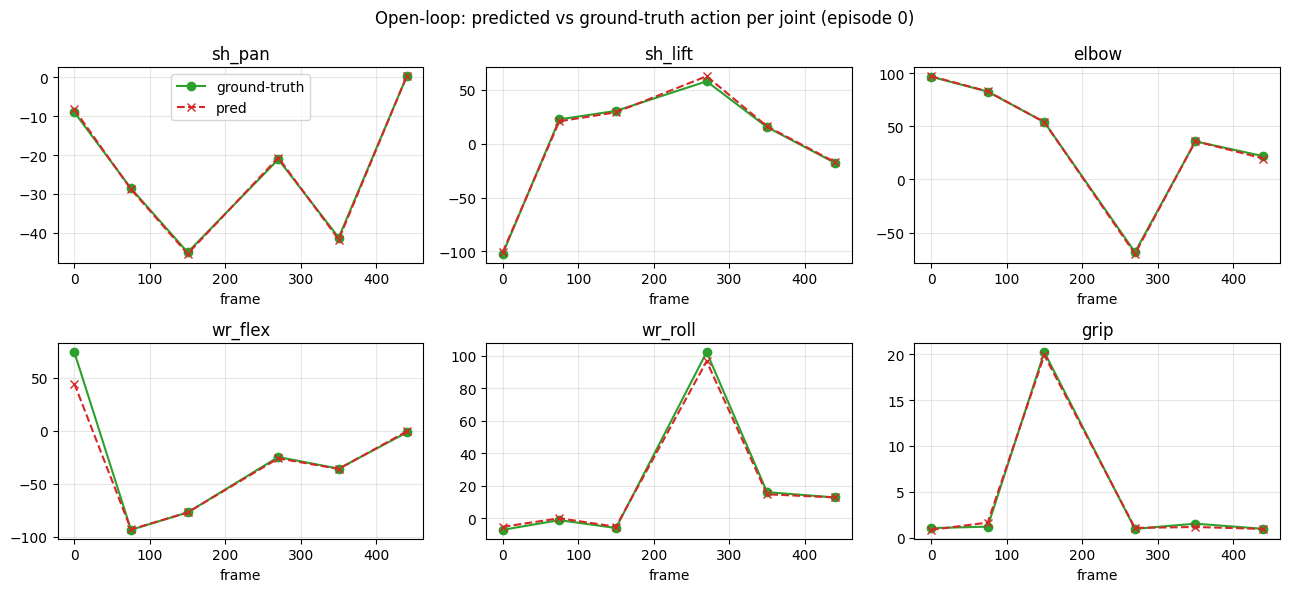

In [5]:
fig, axs = plt.subplots(2, 3, figsize=(13, 6))
for j, ax in enumerate(axs.ravel()):
    ax.plot(frames, gts[:, j], "o-", label="ground-truth", color="tab:green")
    ax.plot(frames, preds[:, j], "x--", label="pred", color="tab:red")
    ax.set_title(JOINTS[j])
    ax.set_xlabel("frame")
    ax.grid(alpha=0.3)
    if j == 0:
        ax.legend()
fig.suptitle("Open-loop: predicted vs ground-truth action per joint (episode 0)")
plt.tight_layout()
plt.show()

## 4. How to read this

- **Lines overlap & both move** (pred follows GT from approach to pour) → model + pipeline are
  correct. The standstill is a **deploy-time observation** problem: the live camera images or the
  reported `observation.state` differ from training (color/space/resolution/crop, camera
  assignment, or a state scale/units mismatch). Next: dump a live deploy observation and diff it
  against a dataset frame.

- **Red (pred) flat / far from green** → the model itself is not conditioning on inputs. Since
  normalization + preprocessing are already cleared, suspect the **weights**: undertrained or a
  mis-saved checkpoint produce exactly this near-constant output.

## 5. Same replay, but with JPEG q90 transport (matches the deploy config)

Deploy runs with `image_compress_enable=true, quality=90`, so the model actually saw **JPEG-degraded** frames. The replay above used **raw** frames. If raw tracks GT but JPEG collapses toward home, the **JPEG transport is the cause**.

In [6]:
JPEG_QUALITY = 90  # matches deploy config image_compress_quality
import cv2
def jpeg_roundtrip(img_chw, quality=JPEG_QUALITY):
    # (3,H,W)[0,1] -> exact server transport: cv2.imencode('.jpg',q) then cv2.imdecode (same channel order)
    arr = (img_chw.detach().cpu().permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
    ok, enc = cv2.imencode('.jpg', arr, [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return torch.from_numpy(dec).permute(2, 0, 1).float() / 255.0

preds_j = []
for gi in idxs:
    item = ds[gi]
    obs = {'observation.state': item['observation.state'].unsqueeze(0)}
    for k in img_keys:
        if k in item:
            im = item[k]
            if im.dtype == torch.uint8:
                im = im.float() / 255.0
            obs[k] = jpeg_roundtrip(im).unsqueeze(0)
    obs['task'] = item.get('task', 'Pour from orange cup into blue cup.')
    policy.reset()
    with torch.no_grad():
        chunk = policy.predict_action_chunk(pre(obs))
    if chunk.ndim != 3:
        chunk = chunk.unsqueeze(0)
    preds_j.append(post(chunk[:, 0, :]).detach().cpu().numpy().ravel()[:6])
preds_j = np.stack(preds_j)
for i, fr in enumerate(frames):
    print(f'frame {fr:3d} | raw {np.round(preds[i],1)} | jpeg {np.round(preds_j[i],1)} | gt {np.round(gts[i],1)}')
print(f'MAE raw-vs-gt {np.abs(preds-gts).mean():.2f} | MAE jpeg-vs-gt {np.abs(preds_j-gts).mean():.2f}')
print('If jpeg MAE blows up / collapses toward home -> JPEG q90 transport is a (the) cause.')

frame   0 | raw [  -8.3 -100.7   97.2   44.6   -5.3    0.9] | jpeg [  -7.  -104.6   97.4   59.4   -7.2    0.9] | gt [  -9.  -102.2   96.7   74.2   -7.2    1. ]
frame  75 | raw [-28.8  20.8  82.9 -92.9  -0.    1.6] | jpeg [-29.1  20.8  82.9 -92.1   0.    1.1] | gt [-28.6  22.6  82.7 -93.3  -1.2   1.2]
frame 150 | raw [-45.4  29.2  53.9 -76.9  -5.2  19.9] | jpeg [-43.9  29.7  55.7 -77.9  -6.2   6.8] | gt [-45.   30.5  54.  -77.   -6.   20.2]
frame 270 | raw [-20.6  62.7 -70.  -25.9  96.7   1.1] | jpeg [-20.4  61.8 -69.3 -24.1  96.9   1. ] | gt [-21.1  58.  -68.4 -24.7 102.3   1. ]
frame 350 | raw [-41.7  16.2  36.  -35.9  14.7   1.2] | jpeg [-40.3  16.4  34.3 -34.4  16.    1.1] | gt [-41.2  15.4  35.8 -35.6  16.    1.5]
frame 440 | raw [  0.3 -17.   19.7  -0.6  12.8   1. ] | jpeg [  0.8 -16.2  19.6  -0.2  13.4   1.1] | gt [  0.3 -17.8  21.9  -1.5  12.8   1. ]
MAE raw-vs-gt 1.74 | MAE jpeg-vs-gt 1.84
If jpeg MAE blows up / collapses toward home -> JPEG q90 transport is a (the) cause.


## 6. Confirm: does the policy use the image at all? (zero-image ablation)

Re-run the matched replay but feed a **black image** (all zeros, same shape) for every camera. If the predictions stay ~unchanged and still track GT, the policy **ignores the image** (image-blind) — the decisive confirmation.

In [ ]:
# Feed a BLACK image (zeros) for every camera; keys stay present so prepare_images doesn't error.
preds_noimg = []
for gi in idxs:
    item = ds[gi]
    obs = {'observation.state': item['observation.state'].unsqueeze(0)}
    for k in img_keys:
        if k in item:
            im = item[k]
            if im.dtype == torch.uint8:
                im = im.float() / 255.0
            obs[k] = torch.zeros_like(im).unsqueeze(0)
    obs['task'] = item.get('task', 'Pour from orange cup into blue cup.')
    policy.reset()
    with torch.no_grad():
        chunk = policy.predict_action_chunk(pre(obs))
    if chunk.ndim != 3:
        chunk = chunk.unsqueeze(0)
    preds_noimg.append(post(chunk[:, 0, :]).detach().cpu().numpy().ravel()[:6])
preds_noimg = np.stack(preds_noimg)
for i, fr in enumerate(frames):
    print(f'frame {fr:3d} | real-img {np.round(preds[i],1)} | NO-img {np.round(preds_noimg[i],1)} | gt {np.round(gts[i],1)}')
print()
print(f'MAE real-img vs gt : {np.abs(preds-gts).mean():.2f}')
print(f'MAE NO-img   vs gt : {np.abs(preds_noimg-gts).mean():.2f}')
print(f'mean |real - NO-img| (how much the image moves the output): {np.abs(preds-preds_noimg).mean():.2f} deg')
print('If NO-img MAE ~ real MAE and |real-NO-img| ~ 0 -> the policy IGNORES the image (image-blind, CONFIRMED).')

## 7. Does the image matter at the AMBIGUOUS home pose? (start-scene vs end-scene)

Section 6's sample is mostly mid-trajectory, where the **state already determines the action** so the image is redundant. The real question is at the **home pose**, which appears at the start (reach) and the end (stay). Here we hold the state at ~home and swap **only the image** between the start scene and the end scene. If the output barely changes, the model can't use vision to disambiguate even where it matters most.

In [ ]:
def _act(state, imgs):
    obs = {'observation.state': state.reshape(1, -1).float()}
    for k, im in imgs.items():
        obs[k] = im.unsqueeze(0)
    obs['task'] = 'Pour from orange cup into blue cup.'
    policy.reset()
    with torch.no_grad():
        chunk = policy.predict_action_chunk(pre(obs))
    if chunk.ndim != 3:
        chunk = chunk.unsqueeze(0)
    return post(chunk[:, 0, :]).detach().cpu().numpy().ravel()[:6]

def _imgs(gi):
    item = ds[gi]; out = {}
    for k in img_keys:
        if k in item:
            im = item[k]
            if im.dtype == torch.uint8:
                im = im.float() / 255.0
            out[k] = im
    return out

# A) where does the image matter on the section-2 frames?
print('per-frame |real - NO-img| (image influence, summed over joints):')
for i, fr in enumerate(frames):
    d = np.abs(preds[i] - preds_noimg[i])
    print(f'  frame {fr:3d}: per-joint {np.round(d,1)}  sum {d.sum():.1f}')

# B) home-region disambiguation: same ~home pose appears at START (reach) and END (stay)
# (LeRobotDataset v3 has no episode_data_index; episodes are fixed-length contiguous blocks)
total = len(ds)
try:
    nep = int(ds.meta.total_episodes)
except Exception:
    nep = 96
EP_LEN = total // nep
print()
print(f'episodes={nep}, ep_len={EP_LEN}')
start_gi = end_gi = None
for e in range(nep):
    a = e * EP_LEN
    s = ds[a]['observation.state'].numpy()
    if abs(s[1]) < 30 and s[2] < 50:  # flat-ish start near home (not a folded outlier)
        start_gi, end_gi = a, a + EP_LEN - 1; break
if start_gi is None:
    start_gi, end_gi = 0, EP_LEN - 1
print('flat-start episode -> start_gi', start_gi, 'end_gi', end_gi)
st_s = ds[start_gi]['observation.state']; st_e = ds[end_gi]['observation.state']
gt_s = ds[start_gi]['action'].numpy().ravel()[:6]; gt_e = ds[end_gi]['action'].numpy().ravel()[:6]
im_s = _imgs(start_gi); im_e = _imgs(end_gi)
print('START state', np.round(st_s.numpy(), 1), '| gt vel', np.round(gt_s - st_s.numpy(), 1))
print('END   state', np.round(st_e.numpy(), 1), '| gt vel', np.round(gt_e - st_e.numpy(), 1))
A = _act(st_s, im_s); B = _act(st_s, im_e); C = _act(st_e, im_e); D = _act(st_e, im_s)
print()
print('(START state, start img):', np.round(A, 1))
print('(START state, END   img):', np.round(B, 1), ' image-effect |A-B| =', round(float(np.abs(A - B).sum()), 1))
print('(END   state, end   img):', np.round(C, 1))
print('(END   state, START img):', np.round(D, 1), ' image-effect |C-D| =', round(float(np.abs(C - D).sum()), 1))
print()
print('If |A-B| and |C-D| are only a few deg -> swapping the whole scene barely moves the output:')
print('the model cannot use vision to tell start from end EVEN at the ambiguous home pose.')